In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('paper')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

In [2]:
import numpy as np
import pandas as pd

In [3]:
c1 = pd.read_csv('../data/pOXA48/plate_counts.tsv', sep='\t')
c2 = pd.read_csv('../data/PN23/plate_counts.tsv', sep='\t')

In [4]:
c1.groupby(['vial', 'short', 'replicate'])['time'].max()

vial  short            replicate
M0    KAN no drug      rep1         136.0
                       rep2         306.0
M1    KAN 16x MIC      rep1         208.0
                       rep2         306.0
M2    KAN+PVI no drug  rep1         208.0
                       rep2         306.0
M3    KAN+PVI 16x MIC  rep1         208.0
                       rep2         306.0
M4    PVI no drug      rep1         208.0
                       rep2         306.0
M5    PVI 16x MIC      rep1         208.0
                       rep2         306.0
M6    PVB no drug      rep1         208.0
                       rep2         306.0
M7    PVB 16x MIC      rep1         208.0
                       rep2         306.0
Name: time, dtype: float64

In [5]:
c1 = c1[~((c1['vial'] == 'M0') & (c1['replicate'] == 'rep1'))].reset_index(drop=True)

In [6]:
for df in [c1, c2]:
    df['replicate'] = df['replicate'].astype(str).str.replace('rep', '')

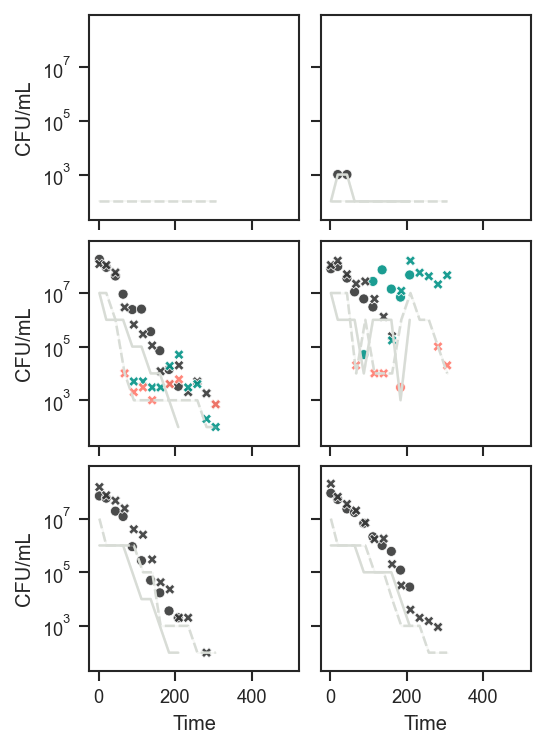

In [7]:
cp = sns.relplot(data=c1[c1['plate'] == 'AMP'],
                 x='time',
                 y='CFU/mL',
                 hue='strain',
                 col='short',
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 col_wrap=2,
                 style='replicate',
                 style_order=['1', '2'],
                 # row_order=['AMP'],
                 # row='plate',
                 height=1.8, aspect=1,
                 alpha=0.9,
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 hue_order=['PL', 'PM', 'LM'],
                 legend=False)

cp.map_dataframe(sns.lineplot,
                 x='time',
                 y='detection_limit',
                 style='replicate',
                 style_order=['1', '2'],
                 color='xkcd:light grey'
                )

cp.set(
       yscale='log',
       xlabel='Time',
       ylabel='CFU/mL',
       ylim=(20, 9E8),
       xlim=(-25, 525),
       xticks=[0,
               200,
               400,]
)
cp.set_titles("")

sns.despine(right=False, top=False)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig('poxa_selective_plating.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_selective_plating.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

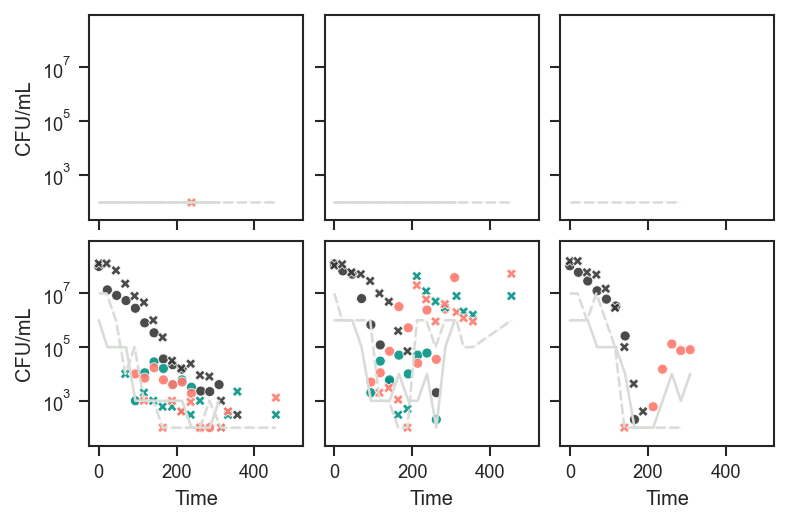

In [8]:
cp = sns.relplot(data=c2[c2['plate'] == 'COL'],
                 x='time',
                 y='CFU/mL',
                 hue='strain',
                 col='short',
                 col_order=['KAN no drug',
                            'KAN 1xMIC',
                            'KAN 2xMIC',
                            'PN23 no drug',
                            'PN23 1xMIC',
                            'PN23 2xMIC'],
                 col_wrap=3,
                 style='replicate',
                 style_order=['1', '2'],
                 # row_order=['AMP'],
                 # row='plate',
                 height=1.95, aspect=0.91,
                 alpha=0.9,
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 hue_order=['PL', 'PM', 'LM'],
                 legend=False)

cp.map_dataframe(sns.lineplot,
                 x='time',
                 y='detection_limit',
                 style='replicate',
                 style_order=['1', '2'],
                 color='xkcd:light grey'
                )

cp.set(
       yscale='log',
       xlabel='Time',
       ylabel='CFU/mL',
       ylim=(20, 9E8),
       xlim=(-25, 525),
       xticks=[0,
               200,
               400,]
)
cp.set_titles("")

sns.despine(right=False, top=False)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig('pn_selective_plating.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_selective_plating.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


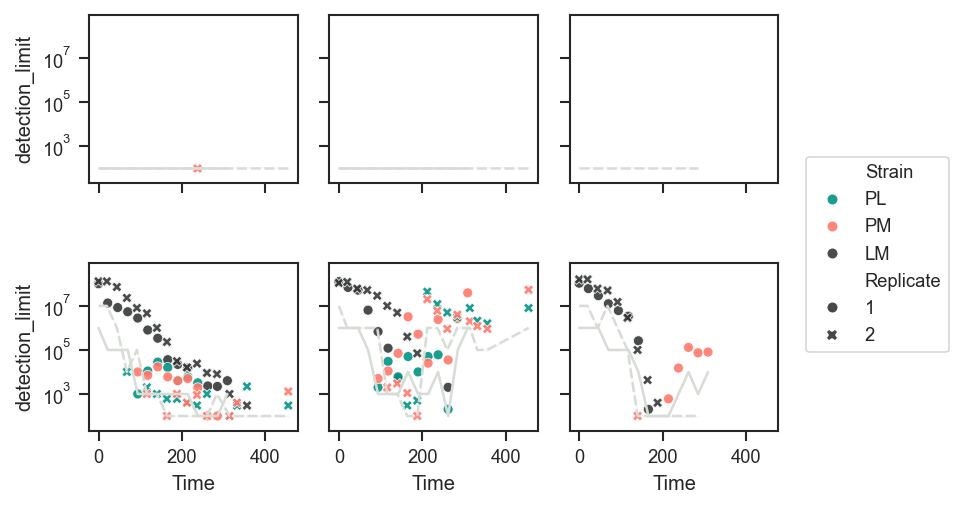

In [9]:
cp = sns.relplot(data=c2[c2['plate'] == 'COL'].rename(columns={'strain': 'Strain',
                                                               'replicate': 'Replicate',
                                                              }),
                 x='time',
                 y='CFU/mL',
                 hue='Strain',
                 col='short',
                 col_order=['KAN no drug',
                            'KAN 1xMIC',
                            'KAN 2xMIC',
                            'PN23 no drug',
                            'PN23 1xMIC',
                            'PN23 2xMIC'],
                 col_wrap=3,
                 style='Replicate',
                 style_order=['1', '2'],
                 # row_order=['AMP'],
                 # row='plate',
                 height=1.9, aspect=0.95,
                 alpha=0.9,
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 hue_order=['PL', 'PM', 'LM'],
                 legend=True,
                )

cp.map_dataframe(sns.lineplot,
                 x='time',
                 y='detection_limit',
                 style='Replicate',
                 style_order=['1', '2'],
                 color='xkcd:light grey'
                )

cp.set(
       yscale='log',
       xlabel='Time',
       ylim=(20, 9E8)
)
cp.set_titles("")

cp._legend.set_frame_on(True)
cp._legend.get_frame().set_facecolor('white')

sns.despine(right=False, top=False)

plt.savefig('pn_selective_plating_legend.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_selective_plating_legend.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


In [10]:
m1 = pd.read_csv('../data/pOXA48/chibio.tsv.gz', sep='\t')
m2 = pd.read_csv('../data/PN23/chibio.tsv.gz', sep='\t')

In [11]:
m1 = m1[~((m1['vial'] == 'M0') & (m1['replicate'] == 'rep1'))].reset_index(drop=True)

In [12]:
for df in [m1, m2]:
    df['replicate'] = df['replicate'].astype(str).str.replace('rep', '')

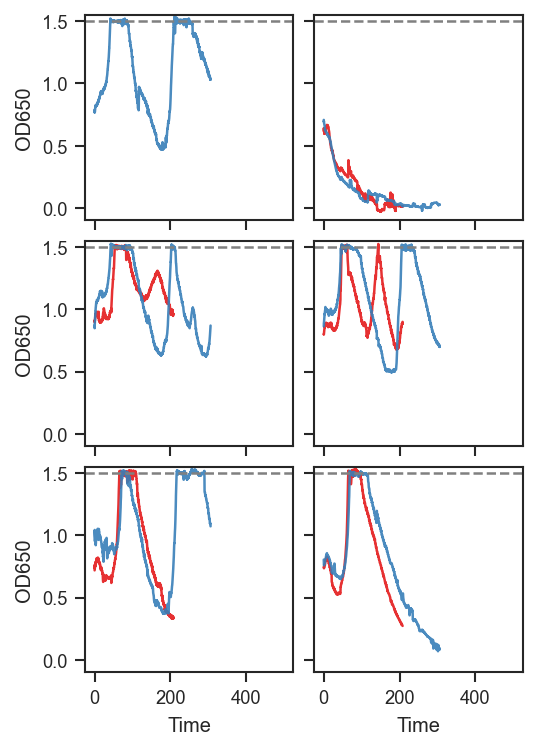

In [13]:
cp = sns.relplot(data=m1,
                 x='time',
                 y='smooth_od',
                 col='short',
                 col_wrap=2,
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 kind='line',
                 height=1.7, aspect=1.08,
                 alpha=0.9,
                 legend=False
                )

cp.set(
    xlabel='Time',
    ylabel='OD650',
    ylim=(-0.1, 1.55),
    xlim=(-25, 525),
    xticks=[0,
            200,
            400,]
)
cp.set_titles("")
cp.map(plt.axhline, y=1.5, color='grey', linestyle='--')

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('poxa_chibio_od.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_chibio_od.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

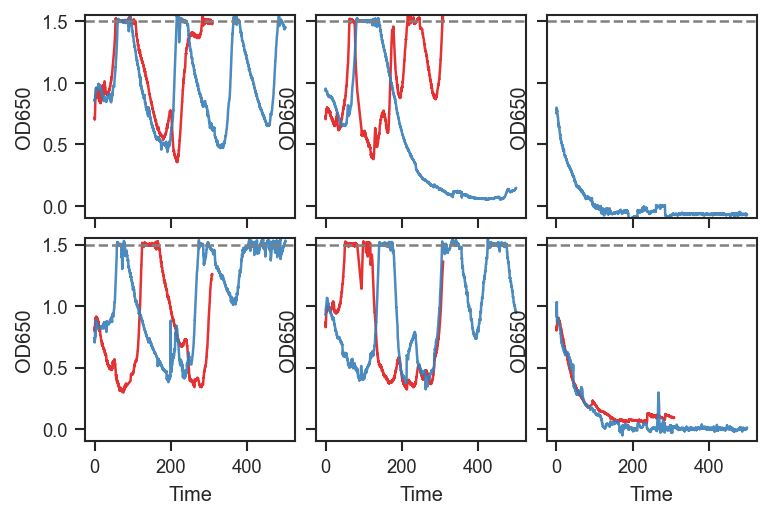

In [14]:
cp = sns.relplot(data=m2,
                 x='time',
                 y='smooth_od',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug',
                            'KAN 1xMIC',
                            'KAN 2xMIC',
                            'PN23 no drug',
                            'PN23 1xMIC',
                            'PN23 2xMIC'],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 kind='line',
                 height=1.78, aspect=0.98,
                 alpha=0.9,
                 legend=False
                )

cp.set(
    xlabel='Time',
    ylabel='OD650',
    ylim=(-0.1, 1.55),
    xlim=(-25, 525),
    xticks=[0,
            200,
            400,]
)
cp.set_titles("")
cp.map(plt.axhline, y=1.5, color='grey', linestyle='--')

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('pn_chibio_od.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_chibio_od.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

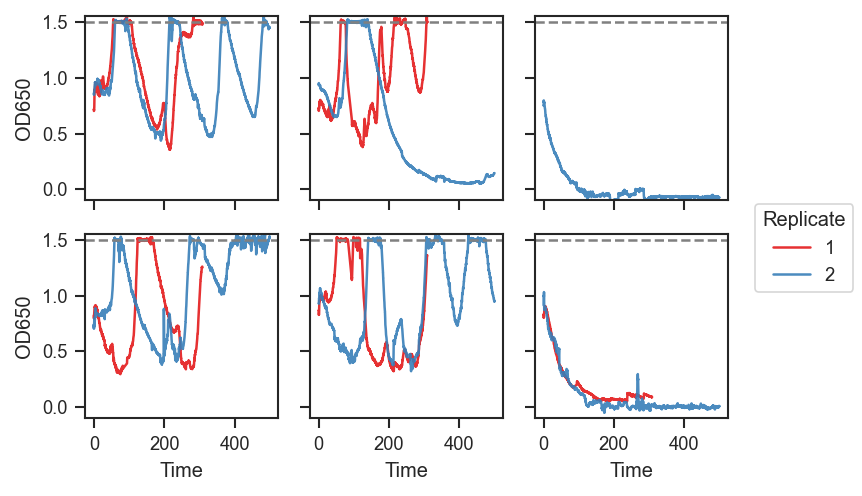

In [15]:
cp = sns.relplot(data=m2.rename(columns={'replicate': 'Replicate'}),
                 x='time',
                 y='smooth_od',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug',
                            'KAN 1xMIC',
                            'KAN 2xMIC',
                            'PN23 no drug',
                            'PN23 1xMIC',
                            'PN23 2xMIC'],
                 hue='Replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=True
                )

cp.set(
    xlabel='Time',
    ylabel='OD650',
    ylim=(-0.1, 1.55)
)
cp.set_titles("")
cp.map(plt.axhline, y=1.5, color='grey', linestyle='--')

cp._legend.set_frame_on(True)
cp._legend.get_frame().set_facecolor('white')

sns.despine(right=False, top=False)

plt.savefig('pn_chibio_od_legend.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_chibio_od_legend.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

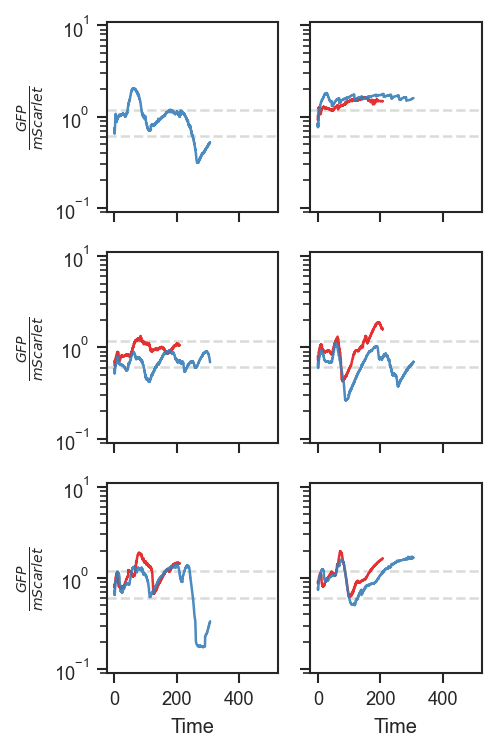

In [16]:
cp = sns.relplot(data=m1,
                 x='time',
                 y='smooth_norm_FP1_emit1_FP2_emit1_ratio',
                 col='short',
                 col_wrap=2,
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
    yscale='log',
    ylim=(0.09, 11),
    ylabel=r'$\frac{GFP}{mScarlet}$',
    xlabel='Time',
    xlim=(-25, 525),
    xticks=[0,
            200,
            400,]
)
cp.set_titles("")

plt.subplots_adjust(wspace=0.1, hspace=0.1)

cp.map(plt.axhline, y=0.61,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=1.18,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

sns.despine(right=False, top=False)

plt.savefig('poxa_chibio_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_chibio_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

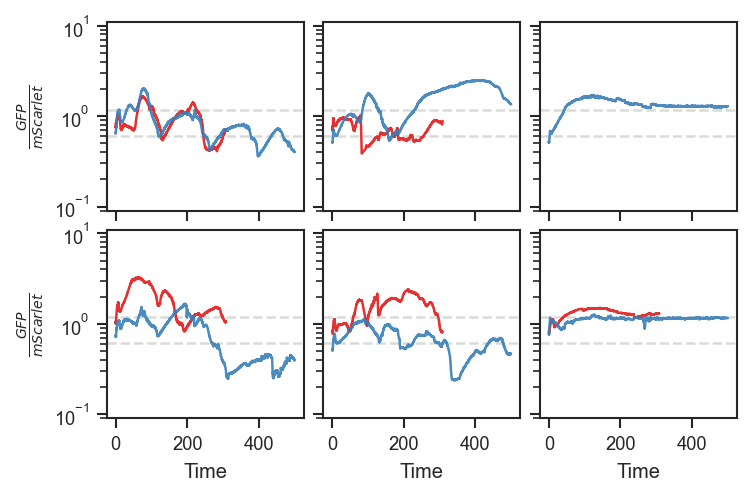

In [17]:
cp = sns.relplot(data=m2,
                 x='time',
                 y='smooth_norm_FP1_emit1_FP2_emit1_ratio',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug', 'KAN 1xMIC', 'KAN 2xMIC',
                            'PN23 no drug', 'PN23 1xMIC', 'PN23 2xMIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
    yscale='log',
    ylim=(0.09, 11),
    ylabel=r'$\frac{GFP}{mScarlet}$',
    xlabel='Time',
    xlim=(-25, 525),
    xticks=[0,
            200,
            400,]
)
cp.set_titles("")

cp.map(plt.axhline, y=0.61,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=1.18,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

sns.despine(right=False, top=False)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig('pn_chibio_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_chibio_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

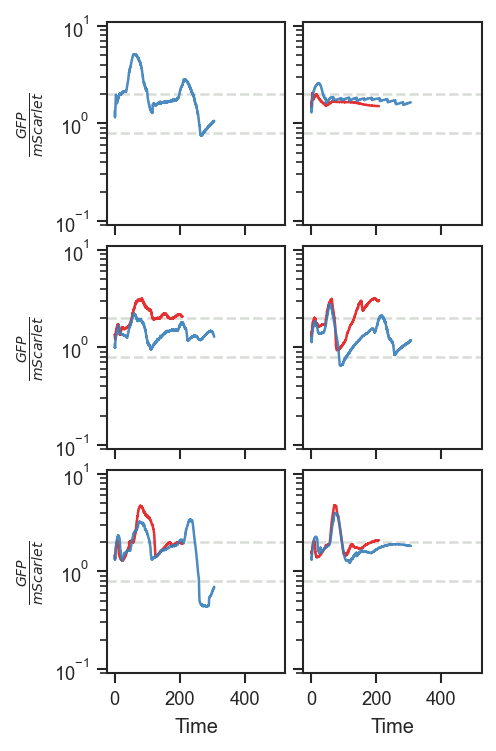

In [18]:
cp = sns.relplot(data=m1,
                 x='time',
                 y='smooth_FP1_emit1_FP2_emit1_ratio',
                 col='short',
                 col_wrap=2,
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
    yscale='log',
    ylim=(0.09, 11),
    ylabel=r'$\frac{GFP}{mScarlet}$',
    xlabel='Time',
    xlim=(-25, 525),
    xticks=[0,
            200,
            400,]
)
cp.set_titles("")

cp.map(plt.axhline, y=0.8,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=2,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

sns.despine(right=False, top=False)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig('poxa_chibio_ratio_raw.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_chibio_ratio_raw.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

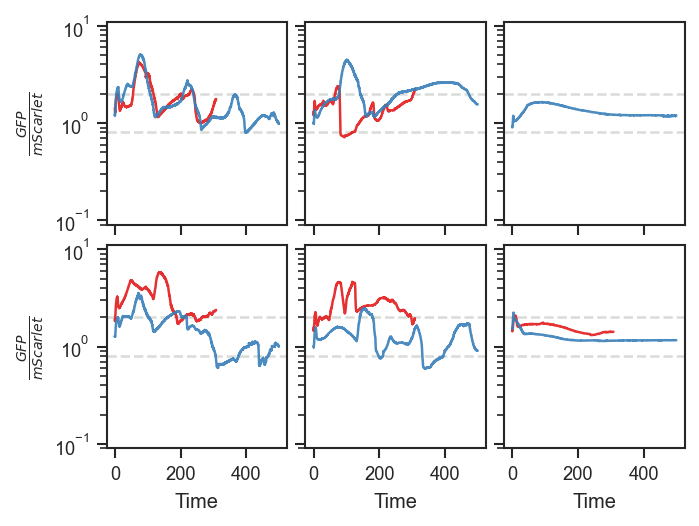

In [19]:
cp = sns.relplot(data=m2,
                 x='time',
                 y='smooth_FP1_emit1_FP2_emit1_ratio',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug', 'KAN 1xMIC', 'KAN 2xMIC',
                            'PN23 no drug', 'PN23 1xMIC', 'PN23 2xMIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 kind='line',
                 height=1.8, aspect=0.88,
                 alpha=0.9,
                 legend=False
                )

cp.set(
    yscale='log',
    ylim=(0.09, 11),
    ylabel=r'$\frac{GFP}{mScarlet}$',
    xlabel='Time',
    xlim=(-25, 525),
    xticks=[0,
            200,
            400,]
)
cp.set_titles("")

cp.map(plt.axhline, y=0.8,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=2,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')

sns.despine(right=False, top=False)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig('pn_chibio_ratio_raw.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_chibio_ratio_raw.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

In [20]:
cr1 = c1.groupby(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time', 'plate']).apply(
               lambda x: (x[x['strain'] == 'PL']['CFU/mL'].mean() /
                          x[x['strain'] == 'PM']['CFU/mL'].mean()) /
                          x['CFU/mL'].sum(),
    include_groups=False).reset_index().rename(columns={0: 'PL / PM'})

In [21]:
cr2 = c2.groupby(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time', 'plate']).apply(
               lambda x: (x[x['strain'] == 'PL']['CFU/mL'].mean() /
                          x[x['strain'] == 'PM']['CFU/mL'].mean()) /
                          x['CFU/mL'].sum(),
    include_groups=False).reset_index().rename(columns={0: 'PL / PM'})

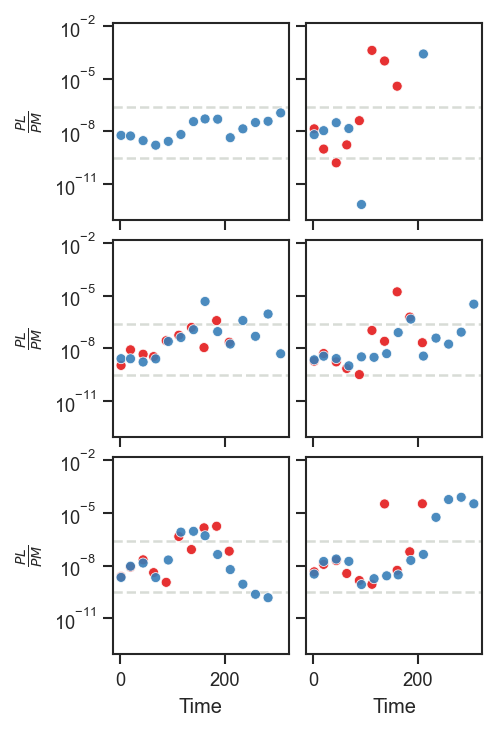

In [22]:
cp = sns.relplot(data=cr1[cr1['plate'] == 'KAN'],
                 x='time',
                 y='PL / PM',
                 col='short',
                 col_wrap=2,
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 # kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel=r'$\frac{PL}{PM}$',
       xlabel='Time',
       ylim=(9E-14, 1.5E-2)
       # ylim=(3E-11, 1.5E-3),
      )

cp.map(plt.axhline, y=3E-10,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=2.5E-7,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.set_titles("")

sns.despine(right=False, top=False)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig('poxa_counting_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_counting_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

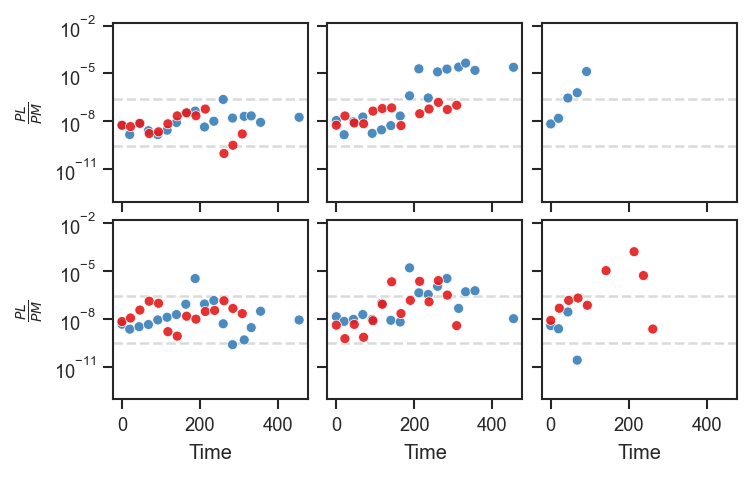

In [23]:
cp = sns.relplot(data=cr2[cr2['plate'] == 'KAN'],
                 x='time',
                 y='PL / PM',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug', 'KAN 1xMIC', 'KAN 2xMIC',
                            'PN23 no drug', 'PN23 1xMIC', 'PN23 2xMIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 # kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel=r'$\frac{PL}{PM}$',
       xlabel='Time',
       ylim=(9E-14, 1.5E-2)
       # ylim=(3E-11, 1.5E-3),
      )

cp.map(plt.axhline, y=3E-10,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=2.5E-7,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.set_titles("")

sns.despine(right=False, top=False)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

plt.savefig('pn_counting_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_counting_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

In [24]:
f1 = pd.read_csv('../data/pOXA48/flow_cytometer.tsv', sep='\t')
f2 = pd.read_csv('../data/PN23/flow_cytometer.tsv', sep='\t')

In [25]:
f1 = f1[~((f1['vial'] == 'M0') & (f1['replicate'] == 'rep1'))].reset_index(drop=True)

In [26]:
for df in [f1, f2]:
    df['replicate'] = df['replicate'].astype(str).str.replace('rep', '')

In [27]:
fr1 = f1.groupby(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time']).apply(
               lambda x: (x[x['strain'] == 'PL']['events'].mean() /
                          x[x['strain'] == 'PM']['events'].mean()),
    include_groups=False).reset_index().rename(columns={0: 'PL / PM'})

In [28]:
fr2 = f2.groupby(['vial', 'replicate', 'name', 'short', 'plasmid', 'drug', 'time']).apply(
               lambda x: (x[x['strain'] == 'PL']['events'].mean() /
                          x[x['strain'] == 'PM']['events'].mean()),
    include_groups=False).reset_index().rename(columns={0: 'PL / PM'})

/tmp/ipykernel_349306/1333859499.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  lambda x: (x[x['strain'] == 'PL']['events'].mean() /
/tmp/ipykernel_349306/1333859499.py:2: RuntimeWarning: invalid value encountered in scalar divide
  lambda x: (x[x['strain'] == 'PL']['events'].mean() /


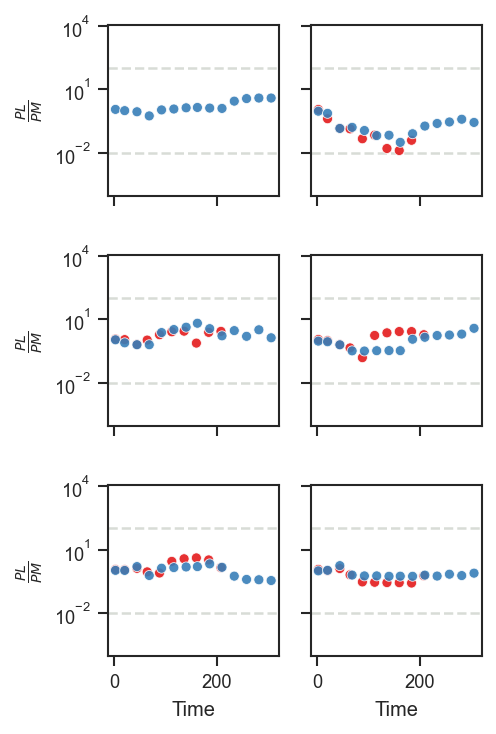

In [29]:
cp = sns.relplot(data=fr1,
                 x='time',
                 y='PL / PM',
                 col='short',
                 col_wrap=2,
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 # kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel=r'$\frac{PL}{PM}$',
       xlabel='Time',
       ylim=(0.00009, 11000)
      )

cp.map(plt.axhline, y=0.01,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=100,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.set_titles("")

sns.despine(right=False, top=False)

plt.savefig('poxa_flow_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_flow_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

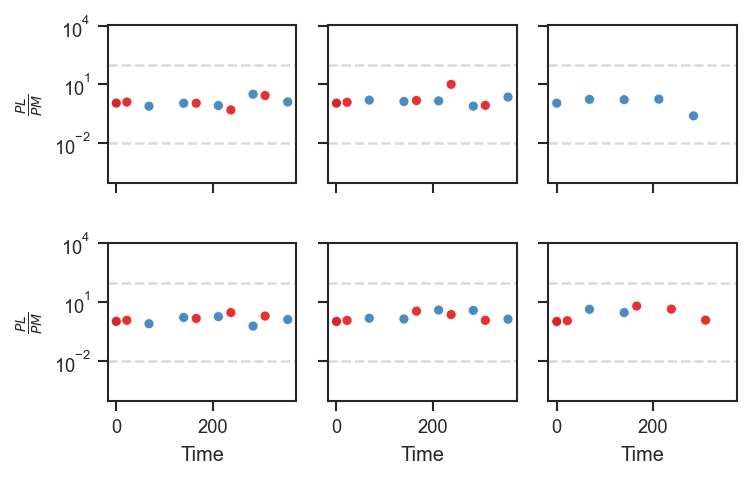

In [30]:
cp = sns.relplot(data=fr2,
                 x='time',
                 y='PL / PM',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug', 'KAN 1xMIC', 'KAN 2xMIC',
                            'PN23 no drug', 'PN23 1xMIC', 'PN23 2xMIC'
                           ],
                 hue='replicate',
                 hue_order=['1', '2'],
                 palette='Set1',
                 # kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel=r'$\frac{PL}{PM}$',
       xlabel='Time',
       ylim=(0.00009, 11000)
      )

cp.map(plt.axhline, y=0.01,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.map(plt.axhline, y=100,
       color='xkcd:light grey',
       zorder=-1,
       linestyle='--')
cp.set_titles("")

sns.despine(right=False, top=False)

plt.savefig('pn_flow_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_flow_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

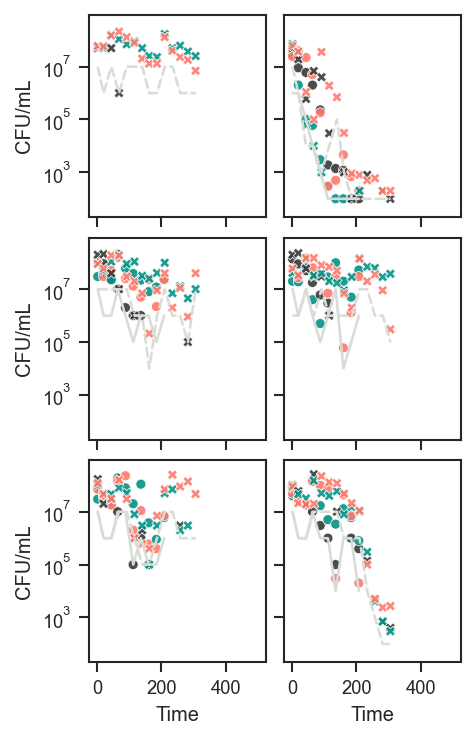

In [31]:
cp = sns.relplot(data=c1[c1['plate'] == 'KAN'],
                 x='time',
                 y='CFU/mL',
                 col='short',
                 col_wrap=2,
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 hue='strain',
                 hue_order=['PL', 'PM', 'LM'],
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 style='replicate',
                 style_order=['1', '2'],
                 # kind='line',
                 height=1.78, aspect=.88,
                 alpha=0.9,
                 legend=False
                )

cp.map_dataframe(sns.lineplot,
                 x='time',
                 y='detection_limit',
                 style='replicate',
                 style_order=['1', '2'],
                 color='xkcd:light grey'
                )

cp.set(
       yscale='log',
       ylabel='CFU/mL',
       xlabel='Time',
       ylim=(20, 9E8),
       xlim=(-25, 525),
       xticks=[0,
               200,
               400,]
      )

cp.set_titles("")

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('poxa_counting.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_counting.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


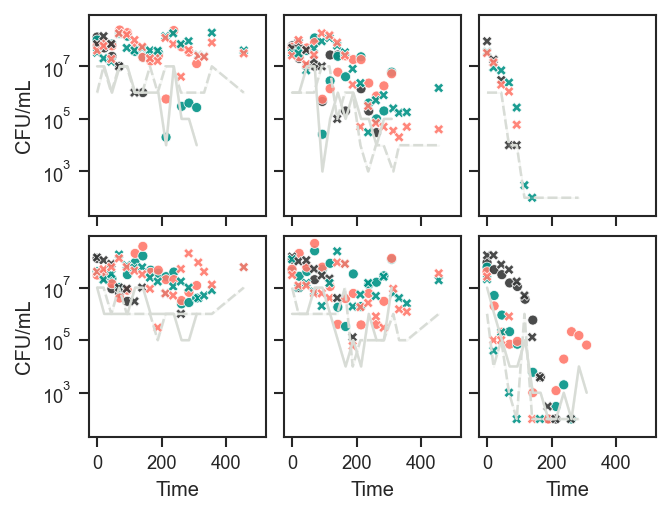

In [32]:
cp = sns.relplot(data=c2[c2['plate'] == 'KAN'],
                 x='time',
                 y='CFU/mL',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug', 'KAN 1xMIC', 'KAN 2xMIC',
                            'PN23 no drug', 'PN23 1xMIC', 'PN23 2xMIC'
                           ],
                 hue='strain',
                 hue_order=['PL', 'PM', 'LM'],
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 style='replicate',
                 style_order=['1', '2'],
                 # kind='line',
                 height=1.92, aspect=0.77,
                 alpha=0.9,
                 legend=False
                )

cp.map_dataframe(sns.lineplot,
                 x='time',
                 y='detection_limit',
                 style='replicate',
                 style_order=['1', '2'],
                 color='xkcd:light grey'
                )

cp.set(
       yscale='log',
       ylabel='CFU/mL',
       xlabel='Time',
       ylim=(20, 9E8),
       xlim=(-25, 525),
       xticks=[0,
               200,
               400,]
      )

cp.set_titles("")

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('pn_counting.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_counting.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);


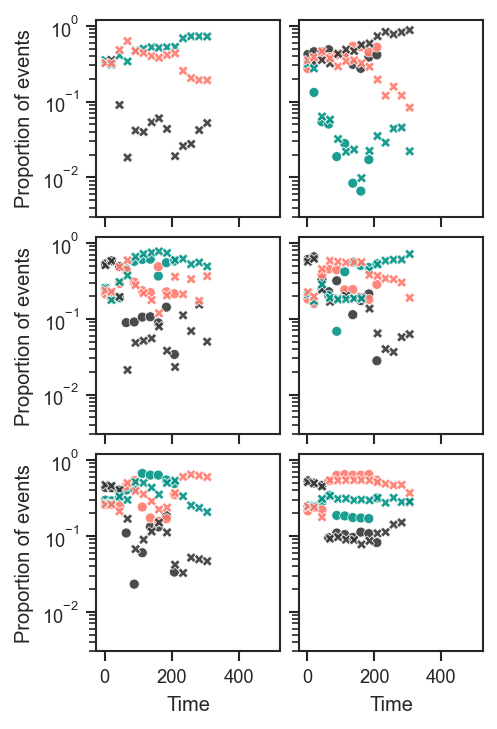

In [33]:
cp = sns.relplot(data=f1,
                 x='time',
                 y='proportion',
                 col='short',
                 col_wrap=2,
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 hue='strain',
                 hue_order=['PL', 'PM', 'LM'],
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 style='replicate',
                 # kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel='Proportion of events',
       xlabel='Time',
       ylim=(0.003, 1.2),
       xlim=(-25, 525),
       xticks=[0,
               200,
               400,]
      )

cp.set_titles("")

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('poxa_flow.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_flow.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

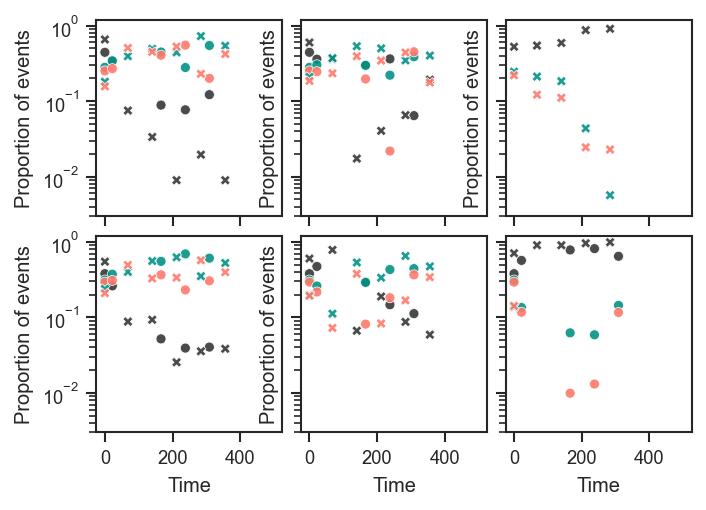

In [34]:
cp = sns.relplot(data=f2,
                 x='time',
                 y='proportion',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug', 'KAN 1xMIC', 'KAN 2xMIC',
                            'PN23 no drug', 'PN23 1xMIC', 'PN23 2xMIC'
                           ],
                 hue='strain',
                 hue_order=['PL', 'PM', 'LM'],
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 style='replicate',
                 # kind='line',
                 height=1.82, aspect=0.865,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel='Proportion of events',
       xlabel='Time',
       ylim=(0.003, 1.2),
       xlim=(-25, 525),
       xticks=[0,
               200,
               400,]
      )

cp.set_titles("")

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('pn_flow.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_flow.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

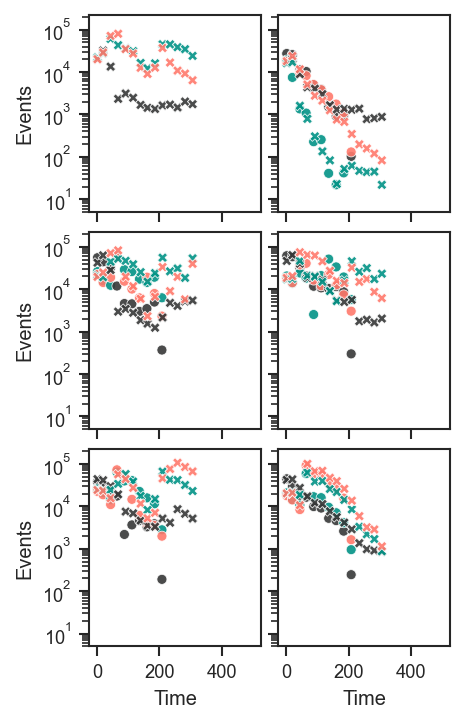

In [35]:
cp = sns.relplot(data=f1,
                 x='time',
                 y='events',
                 col='short',
                 col_wrap=2,
                 col_order=['KAN no drug', 'KAN 16x MIC',
                            'PVI no drug', 'PVI 16x MIC',
                            'PVB no drug', 'PVB 16x MIC'
                           ],
                 hue='strain',
                 hue_order=['PL', 'PM', 'LM'],
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 style='replicate',
                 # kind='line',
                 height=1.7, aspect=1.,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel='Events',
       xlabel='Time',
       ylim=(5, 225000),
       xlim=(-25, 525),
       xticks=[0,
               200,
               400,]
      )

cp.set_titles("")

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('poxa_flow_events.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('poxa_flow_events.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

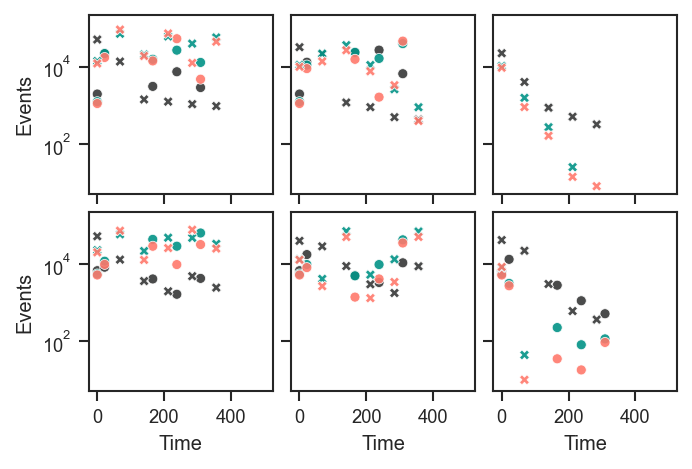

In [36]:
cp = sns.relplot(data=f2,
                 x='time',
                 y='events',
                 col='short',
                 col_wrap=3,
                 col_order=['KAN no drug', 'KAN 1xMIC', 'KAN 2xMIC',
                            'PN23 no drug', 'PN23 1xMIC', 'PN23 2xMIC'
                           ],
                 hue='strain',
                 hue_order=['PL', 'PM', 'LM'],
                 palette=['xkcd:teal',
                          'xkcd:salmon',
                          'xkcd:dark grey'],
                 style='replicate',
                 # kind='line',
                 height=1.7, aspect=0.95,
                 alpha=0.9,
                 legend=False
                )

cp.set(
       yscale='log',
       ylabel='Events',
       xlabel='Time',
       ylim=(5, 225000),
       xlim=(-25, 525),
       xticks=[0,
               200,
               400,]
      )

cp.set_titles("")

plt.subplots_adjust(wspace=0.1, hspace=0.1)

sns.despine(right=False, top=False)

plt.savefig('pn_flow_events.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('pn_flow_events.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

In [37]:
# manuscript: first appearance of transconjugant colonies on selective plates
for df, plate in [(c1, 'AMP'), (c2, 'COL')]:
    d = df[(df['plate'] == plate) & (df['strain'].isin(['PL', 'PM'])) & (df['count'] > 0)]
    print(plate)
    print(d.groupby(['short', 'replicate', 'strain'])['time'].min().unstack().to_string())

AMP
strain                        PL     PM
short           replicate              
KAN+PVI 16x MIC 1           88.0    NaN
                2           92.0   68.0
KAN+PVI no drug 2           68.0   68.0
PVI 16x MIC     1           88.0  184.0
                2          162.0   68.0
PVI no drug     2           92.0   68.0
COL
strain                       PL     PM
short          replicate              
KAN no drug    2            NaN  236.0
KAN+PN23 2xMIC 1          190.0  262.0
PN23 1xMIC     1           94.0   94.0
               2          164.0  116.0
PN23 2xMIC     1            NaN  214.0
               2            NaN  140.0
PN23 no drug   1           94.0   94.0
               2           68.0  116.0


In [38]:
# manuscript: log-linear decline of plasmid-carrying colonies
from scipy import stats

def decline(df, plate, shorts, strains=None):
    d = df[(df['plate'] == plate) & (df['short'].isin(shorts))]
    if strains is not None:
        d = d[d['strain'].isin(strains)]
    tot = d.groupby(['short', 'replicate', 'time'])['CFU/mL'].sum(min_count=1).reset_index()
    tot = tot[tot['CFU/mL'] > 0].dropna()
    out = []
    for (s, r), g in tot.groupby(['short', 'replicate']):
        lr = stats.linregress(g['time'], np.log10(g['CFU/mL']))
        out.append((s, r, len(g), lr.slope * 100, lr.rvalue ** 2))
    return pd.DataFrame(out, columns=['short', 'rep', 'n', 'slope_log10_per_100h', 'r2'])

print(decline(c1, 'AMP', ['PVI no drug']).to_string(index=False))
print(decline(c2, 'COL', ['PN23 no drug']).to_string(index=False))
print(decline(c1, 'AMP', ['PVB no drug', 'PVB 16x MIC'], ['LM']).to_string(index=False))

      short rep  n  slope_log10_per_100h       r2
PVI no drug   1 10             -2.290618 0.983293
PVI no drug   2 14             -1.657736 0.915132
       short rep  n  slope_log10_per_100h       r2
PN23 no drug   1 14             -1.536889 0.966420
PN23 no drug   2 17             -1.370213 0.904881
      short rep  n  slope_log10_per_100h       r2
PVB 16x MIC   1 10             -1.628987 0.980685
PVB 16x MIC   2 13             -2.073017 0.972948
PVB no drug   1 10             -2.444837 0.984493
PVB no drug   2 12             -2.314600 0.981259


In [39]:
# manuscript: Chi.Bio GFP/mScarlet threshold crossings for the three shifted runs
def windows(d, thr, above):
    d = d.dropna(subset=['smooth_FP1_emit1_FP2_emit1_ratio']).sort_values('time')
    v = d['smooth_FP1_emit1_FP2_emit1_ratio']
    mask = (v > thr).values if above else (v < thr).values
    t, runs, start = d['time'].values, [], None
    for i, flag in enumerate(mask):
        if flag and start is None:
            start = t[i]
        elif not flag and start is not None:
            runs.append((start, t[i - 1]))
            start = None
    if start is not None:
        runs.append((start, t[-1]))
    return [(round(x, 1), round(y, 1), round(y - x, 1)) for x, y in runs if y - x >= 5]

for lab, df, short, thr, above in [('PVB no drug rep2', m1, 'PVB no drug', 0.8, False),
                                   ('PN23 no drug rep2', m2, 'PN23 no drug', 0.8, False),
                                   ('KAN 1xMIC rep2', m2, 'KAN 1xMIC', 2.0, True)]:
    print(lab, windows(df[(df['short'] == short) & (df['replicate'] == '2')], thr, above))

PVB no drug rep2 [(np.float64(259.2), np.float64(306.2), np.float64(47.0))]
PN23 no drug rep2 [(np.float64(307.0), np.float64(376.9), np.float64(70.0)), (np.float64(438.3), np.float64(467.2), np.float64(28.9))]
KAN 1xMIC rep2 [(np.float64(77.5), np.float64(142.1), np.float64(64.5)), (np.float64(256.6), np.float64(472.5), np.float64(215.9))]


In [40]:
# manuscript: fold changes in the PL/PM ratio inside those windows
from scipy.stats import gmean

def fold(counts, flow, short, t0, t1, num, den):
    cc = counts[(counts['short'] == short) & (counts['replicate'] == '2') & (counts['plate'] == 'KAN')]
    p = cc.pivot_table(index='time', columns='strain', values='CFU/mL')
    ff = flow[(flow['short'] == short) & (flow['replicate'] == '2')]
    q = ff.pivot_table(index='time', columns='strain', values='events')
    for name, tab in [('plates', p), ('flow', q)]:
        r = (tab[num] / tab[den]).dropna()
        base, win = r[r.index < t0], r[(r.index >= t0) & (r.index <= t1)]
        if len(base) and len(win):
            print(f'  {name}: baseline {gmean(base):.2f}, '
                  + ', '.join(f'{t:.0f} h {v / gmean(base):.1f}x' for t, v in win.items()))

print('PVB no drug rep2'); fold(c1, f1, 'PVB no drug', 259, 310, 'PM', 'PL')
print('PN23 no drug rep2'); fold(c2, f2, 'PN23 no drug', 307, 470, 'PM', 'PL')
print('KAN 1xMIC rep2'); fold(c2, f2, 'KAN 1xMIC', 257, 473, 'PL', 'PM')

PVB no drug rep2
  plates: baseline 1.38, 282 h 33.9x
  flow: baseline 0.91, 282 h 2.9x, 306 h 3.2x
PN23 no drug rep2
  plates: baseline 0.89, 314 h 25.3x, 332 h 9.0x, 356 h 1.8x, 455 h 1.1x
  flow: baseline 0.89, 356 h 0.8x
KAN 1xMIC rep2
  plates: baseline 1.10, 260 h 6.6x, 284 h 14.5x, 314 h 6.5x, 332 h 7.7x, 356 h 3.3x, 455 h 34.1x
  flow: baseline 1.37, 284 h 0.6x, 356 h 1.7x


In [41]:
# manuscript: LM density on selective plates at the first time point
for df, plate in [(c1, 'AMP'), (c2, 'COL')]:
    d = df[(df['plate'] == plate) & (df['strain'] == 'LM')].dropna(subset=['CFU/mL'])
    first = d.loc[d.groupby(['short', 'replicate'])['time'].idxmin()]
    print(first[['short', 'replicate', 'time', 'CFU/mL']].to_string(index=False))

          short replicate  time      CFU/mL
    KAN 16x MIC         1  20.0      1000.0
KAN+PVI 16x MIC         1   2.0  12000000.0
KAN+PVI 16x MIC         2   2.0  24000000.0
KAN+PVI no drug         1   2.0  14000000.0
KAN+PVI no drug         2   2.0  18000000.0
    PVB 16x MIC         1   2.0  89000000.0
    PVB 16x MIC         2   2.0 200000000.0
    PVB no drug         1   2.0  70000000.0
    PVB no drug         2   2.0 150000000.0
    PVI 16x MIC         1   2.0  80000000.0
    PVI 16x MIC         2   2.0 110000000.0
    PVI no drug         1   2.0 180000000.0
    PVI no drug         2   2.0 120000000.0
         short replicate  time      CFU/mL
KAN+PN23 2xMIC         1  22.0   8100000.0
    PN23 1xMIC         1   0.0 126000000.0
    PN23 1xMIC         2   0.0 110000000.0
    PN23 2xMIC         1   0.0 107000000.0
    PN23 2xMIC         2   0.0 160000000.0
  PN23 no drug         1   0.0 101000000.0
  PN23 no drug         2   0.0 130000000.0
